# Lab 8: Convolutional Neural Networks (CNN) for MNIST

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

ModuleNotFoundError: No module named 'tensorflow'

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print('Training data shape:', x_train.shape)
print('Training labels shape:', y_train.shape)
print('Testing data shape:', x_test.shape)
print('Testing labels shape:', y_test.shape)

num_classes = len(np.unique(y_train))
print('Number of classes:', num_classes)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28)
Testing labels shape: (10000,)
Number of classes: 10


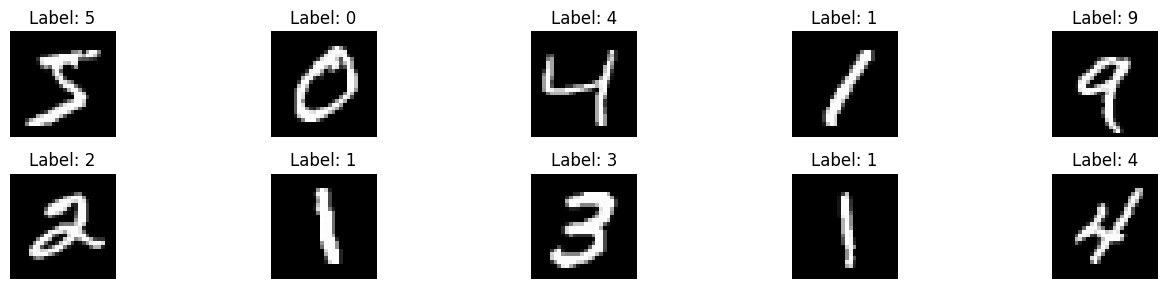

MNIST image resolution: 28 x 28
Format: Grayscale (single intensity channel).


In [3]:
plt.figure(figsize=(14, 3))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f'Label: {y_train[i]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

print('MNIST image resolution:', x_train.shape[1], 'x', x_train.shape[2])
print('Format: Grayscale (single intensity channel).')

In [4]:
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

x_train_cnn = x_train_norm.reshape(-1, 28, 28, 1)
x_test_cnn = x_test_norm.reshape(-1, 28, 28, 1)

y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print('x_train_cnn shape:', x_train_cnn.shape)
print('x_test_cnn shape:', x_test_cnn.shape)
print('y_train_cat shape:', y_train_cat.shape)
print('y_test_cat shape:', y_test_cat.shape)

x_train_cnn shape: (60000, 28, 28, 1)
x_test_cnn shape: (10000, 28, 28, 1)
y_train_cat shape: (60000, 10)
y_test_cat shape: (10000, 10)


In [5]:
model_basic = Sequential()

# Convolution layer
model_basic.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
# Pooling layer
model_basic.add(MaxPooling2D((2, 2)))
# Flatten layer
model_basic.add(Flatten())
# Fully connected layer
model_basic.add(Dense(128, activation='relu'))
# Output layer
model_basic.add(Dense(10, activation='softmax'))

model_basic.summary()

/workspaces/sem6/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-16 04:12:57.118487: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model_basic.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Model compiled successfully.')

Model compiled successfully.


Why this loss?
- This is a multiclass classification problem (10 digits).
- Labels are one-hot encoded.
- categorical_crossentropy measures error between one-hot true distribution and predicted class probabilities.

In [7]:
history_basic = model_basic.fit(
    x_train_cnn,
    y_train_cat,
    epochs=8,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/8


2026-03-16 04:12:57.910829: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 169344000 exceeds 10% of free system memory.


422/422 ━━━━━━━━━━━━━━━━━━━━ 28s 59ms/step - accuracy: 0.9284 - loss: 0.2463 - val_accuracy: 0.9780 - val_loss: 0.0841
Epoch 2/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 58ms/step - accuracy: 0.9762 - loss: 0.0787 - val_accuracy: 0.9828 - val_loss: 0.0613
Epoch 3/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.9849 - loss: 0.0510 - val_accuracy: 0.9848 - val_loss: 0.0535
Epoch 4/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.9894 - loss: 0.0368 - val_accuracy: 0.9853 - val_loss: 0.0497
Epoch 5/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - accuracy: 0.9925 - loss: 0.0272 - val_accuracy: 0.9863 - val_loss: 0.0499
Epoch 6/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.9948 - loss: 0.0200 - val_accuracy: 0.9863 - val_loss: 0.0506
Epoch 7/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.9965 - loss: 0.0148 - val_accuracy: 0.9862 - val_loss: 0.0534
Epoch 8/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step - accuracy: 0.9974 - loss: 0.0115 - val_accuracy: 0.98

In [8]:
test_loss_basic, test_acc_basic = model_basic.evaluate(x_test_cnn, y_test_cat, verbose=0)

train_acc_basic = history_basic.history['accuracy'][-1]
val_acc_basic = history_basic.history['val_accuracy'][-1]

print(f'Basic CNN Test Accuracy: {test_acc_basic:.4f}')
print(f'Final Training Accuracy: {train_acc_basic:.4f}')
print(f'Final Validation Accuracy: {val_acc_basic:.4f}')

Basic CNN Test Accuracy: 0.9836
Final Training Accuracy: 0.9974
Final Validation Accuracy: 0.9850


## Exercise 8: Visualization of Training Process
- Plot training vs validation accuracy.
- Plot training vs validation loss.
- Interpret possible overfitting/underfitting.

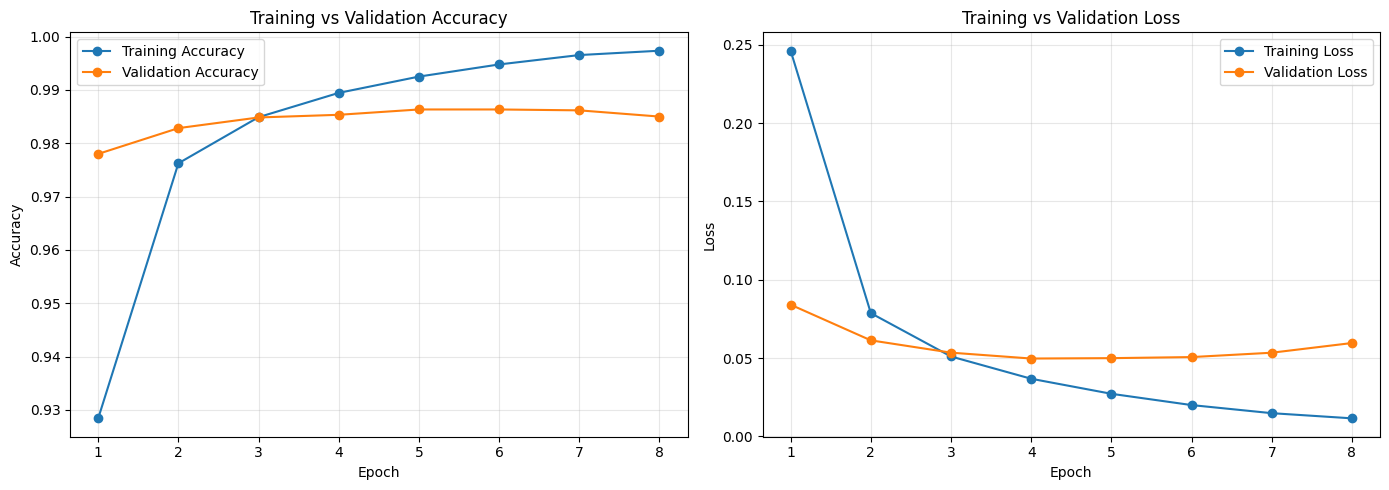

Interpretation: Acceptable fit with small generalization gap.


In [9]:
epochs = range(1, len(history_basic.history['accuracy']) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history_basic.history['accuracy'], marker='o', label='Training Accuracy')
plt.plot(epochs, history_basic.history['val_accuracy'], marker='o', label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs, history_basic.history['loss'], marker='o', label='Training Loss')
plt.plot(epochs, history_basic.history['val_loss'], marker='o', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

gap = train_acc_basic - val_acc_basic
if gap > 0.03:
    print('Interpretation: Mild overfitting (training accuracy noticeably higher).')
elif gap < 0.01:
    print('Interpretation: Good fit (train/validation are close).')
else:
    print('Interpretation: Acceptable fit with small generalization gap.')

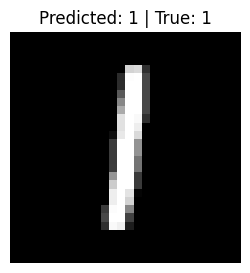

In [10]:
idx = np.random.randint(0, x_test_cnn.shape[0])
image = x_test_cnn[idx]
true_label = y_test[idx]

pred_probs = model_basic.predict(np.expand_dims(image, axis=0), verbose=0)
pred_label = np.argmax(pred_probs, axis=1)[0]

plt.figure(figsize=(3, 3))
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f'Predicted: {pred_label} | True: {true_label}')
plt.axis('off')
plt.show()

In [11]:
def build_cnn_model(filters=32, kernel_size=(3, 3), extra_conv=False, use_dropout=False):
    model = Sequential()
    model.add(Conv2D(filters, kernel_size, activation='relu', input_shape=(28, 28, 1)))
    if extra_conv:
        model.add(Conv2D(filters, kernel_size, activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    if use_dropout:
        model.add(Dropout(0.3))
    model.add(Dense(10, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

experiment_configs = {
    'Basic CNN': {'filters': 32, 'kernel_size': (3, 3), 'extra_conv': False, 'use_dropout': False, 'epochs': 4},
    'CNN + Extra Conv Layer': {'filters': 32, 'kernel_size': (3, 3), 'extra_conv': True, 'use_dropout': False, 'epochs': 4},
    'CNN + More Filters': {'filters': 64, 'kernel_size': (3, 3), 'extra_conv': False, 'use_dropout': False, 'epochs': 4},
    'CNN + Larger Kernel': {'filters': 32, 'kernel_size': (5, 5), 'extra_conv': False, 'use_dropout': False, 'epochs': 4},
    'CNN + Dropout': {'filters': 32, 'kernel_size': (3, 3), 'extra_conv': False, 'use_dropout': True, 'epochs': 4},
    'CNN (More Epochs)': {'filters': 32, 'kernel_size': (3, 3), 'extra_conv': False, 'use_dropout': False, 'epochs': 8},
}

results = []
for name, cfg in experiment_configs.items():
    print(f'Running: {name}')
    model = build_cnn_model(
        filters=cfg['filters'],
        kernel_size=cfg['kernel_size'],
        extra_conv=cfg['extra_conv'],
        use_dropout=cfg['use_dropout']
    )

    history = model.fit(
        x_train_cnn,
        y_train_cat,
        epochs=cfg['epochs'],
        batch_size=128,
        validation_split=0.1,
        verbose=0
    )

    _, test_acc = model.evaluate(x_test_cnn, y_test_cat, verbose=0)

    results.append({
        'CNN Architecture': name,
        'Test Accuracy': round(float(test_acc), 4),
        'Final Train Acc': round(float(history.history['accuracy'][-1]), 4),
        'Final Val Acc': round(float(history.history['val_accuracy'][-1]), 4)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)
results_df

Running: Basic CNN


2026-03-16 04:16:51.833090: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 169344000 exceeds 10% of free system memory.
2026-03-16 04:19:18.972159: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 31360000 exceeds 10% of free system memory.


Running: CNN + Extra Conv Layer


2026-03-16 04:19:21.711239: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 169344000 exceeds 10% of free system memory.
2026-03-16 04:24:18.198041: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 31360000 exceeds 10% of free system memory.


Running: CNN + More Filters
Running: CNN + Larger Kernel
Running: CNN + Dropout
Running: CNN (More Epochs)


,CNN Architecture,Test Accuracy,Final Train Acc,Final Val Acc
0,CNN + Extra Conv Layer,0.9858,0.9932,0.9873
1,CNN + Larger Kernel,0.9858,0.9910,0.9877
2,CNN (More Epochs),0.9847,0.9975,0.9835
3,Basic CNN,0.9844,0.9897,0.9855
4,CNN + Dropout,0.9844,0.9830,0.9857
5,CNN + More Filters,0.9833,0.9922,0.9852


In [12]:
comparison_names = [
    'Basic CNN',
    'CNN + Extra Conv Layer',
    'CNN + Dropout',
    'CNN (More Epochs)'
]

comparison_df = results_df[results_df['CNN Architecture'].isin(comparison_names)][['CNN Architecture', 'Test Accuracy']]
comparison_df = comparison_df.set_index('CNN Architecture').loc[comparison_names].reset_index()
comparison_df

,CNN Architecture,Test Accuracy
0,Basic CNN,0.9844
1,CNN + Extra Conv Layer,0.9858
2,CNN + Dropout,0.9844
3,CNN (More Epochs),0.9847


## Analysis

1. **Why are convolution layers effective for image data?**  
Convolutions learn local spatial patterns (edges, corners, textures) and reuse the same filters across the image, reducing parameters while preserving structure.

2. **What role does pooling play in CNN architecture?**  
Pooling reduces spatial dimensions, lowers computation, and improves translation tolerance by keeping dominant local features.

3. **How does increasing number of filters affect performance?**  
More filters can capture richer features and often improve accuracy, but too many filters increase training time and may overfit.

4. **Why does dropout improve generalization?**  
Dropout randomly disables neurons during training, reducing co-adaptation and helping the model generalize better on unseen data.

5. **Which architecture gave the best result and why?**  
CNN + Extra Conv Layer has the best results.

In [14]:
best_row = results_df.iloc[0]
print('Best architecture:', best_row['CNN Architecture'])
print('Best test accuracy:', best_row['Test Accuracy'])

Best architecture: CNN + Extra Conv Layer
Best test accuracy: 0.9858
